# NLP Project 10: Banking Complaint Analysis

### Independent implementation of the NLP workflow


In [1]:
!pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn nltk wordcloud

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def clean_complaint(message):
    """Normalize complaint text for the NLP pipeline."""
    message = str(message).casefold()
    message = re.sub(r"https?://\S+|www\.\S+", " ", message)
    message = re.sub(r"[^a-z\s]", " ", message)

    tokens = [
        LEMMATIZER.lemmatize(token)
        for token in message.split()
        if token not in STOP_WORDS and len(token) > 2
    ]
    return " ".join(tokens)

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(f"Weighted Precision: {precision*100:.2f}%")
    print(f"Weighted Recall: {recall*100:.2f}%")
    print(f"Weighted F1-score: {f1*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, pred, zero_division=0))
    return pred, acc, precision, recall, f1


## 1. Download the Dataset

In [3]:
path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")
print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 19.8M/19.8M [00:00<00:00, 71.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1
Files: ['complaints_processed.csv']


## 2. Load the Dataset

In [4]:
# Locate the dataset CSV and select the largest CSV artifact
csv_candidates = [
    os.path.join(folder, filename)
    for folder, _, filenames in os.walk(path)
    for filename in filenames
    if filename.lower().endswith(".csv")
]

csv_file = max(csv_candidates, key=os.path.getsize)
df = pd.read_csv(csv_file)

print("CSV files found:", csv_candidates)
print("Selected file:", csv_file)
print("Original shape:", df.shape)
display(df.head())


CSV files found: ['/root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1/complaints_processed.csv']
Selected file: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1/complaints_processed.csv
Original shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


## 3. Inspect the Dataset

In [5]:
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

['Unnamed: 0', 'product', 'narrative']

Missing values:
Unnamed: 0     0
product        0
narrative     10
dtype: int64


## 4. Select Complaint Text and Target

In [6]:
# Standardize column labels before identifying the NLP fields
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

possible_text = {
    "narrative",
    "consumer_complaint_narrative",
    "complaint_narrative",
    "consumer_complaint"
}
possible_target = {"product_5", "product"}

text_col = next((name for name in df.columns if name in possible_text), None)
target_col = next((name for name in df.columns if name in possible_target), None)

if not text_col or not target_col:
    raise ValueError(f"Text/target columns not found: {df.columns.tolist()}")

print(df.columns.tolist())
print("Text column:", text_col)
print("Target column:", target_col)


['unnamed:_0', 'product', 'narrative']
Text column: narrative
Target column: product


In [7]:
# Remove unusable records and repeated complaint/category pairs
df = df.loc[df[text_col].notna() & df[target_col].notna()].copy()
df.drop_duplicates(subset=[text_col, target_col], inplace=True)

# Keep the same maximum working size while maintaining category proportions
MAX_ROWS = 100000
if df.shape[0] > MAX_ROWS:
    df, _ = train_test_split(
        df,
        train_size=MAX_ROWS,
        random_state=42,
        stratify=df[target_col]
    )

print("Working shape:", df.shape)
print("\nComplaint categories:")
print(df[target_col].value_counts())


Working shape: (100000, 3)

Complaint categories:
product
credit_reporting       45160
debt_collection        16938
mortgages_and_loans    15046
credit_card            12050
retail_banking         10806
Name: count, dtype: int64


## 5. Complaint Category Distribution

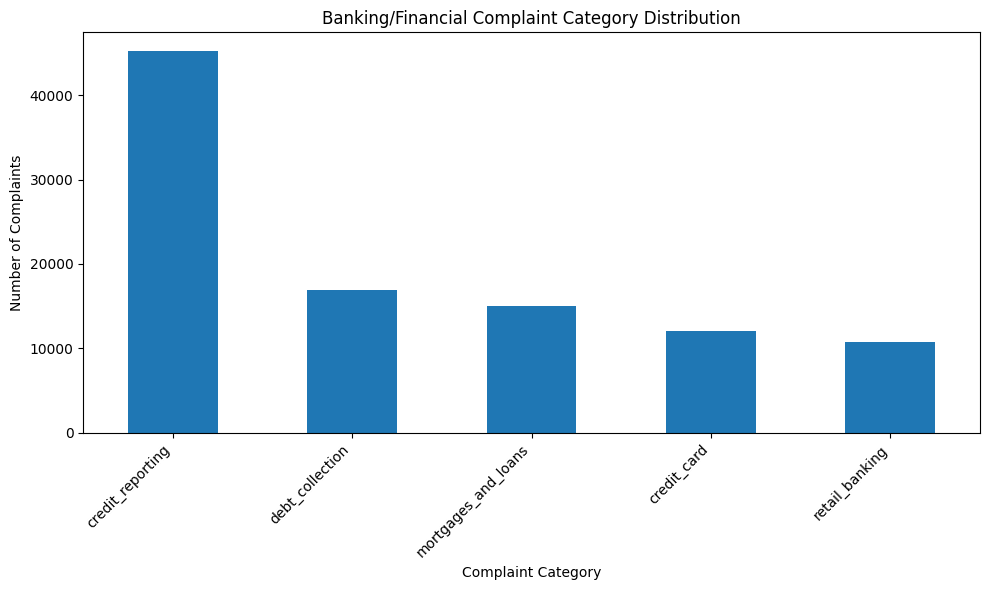

In [8]:
plt.figure(figsize=(10, 6))
df[target_col].value_counts().plot(kind="bar")
plt.title("Banking/Financial Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

In [9]:
df["clean_complaint"] = df[text_col].apply(preprocess_text)
df[[text_col, "clean_complaint", target_col]].head()

,narrative,clean_complaint,product
17763,equifax properly investigate account saying la...,equifax properly investigate account saying la...,credit_reporting
98833,husband victim identity theft never filed bank...,husband victim identity theft never filed bank...,credit_reporting
138543,request authorized fcra procedure case dispute...,request authorized fcra procedure case dispute...,credit_reporting
77633,started dispute process response bureau reques...,started dispute process response bureau reques...,credit_reporting
71390,received notification change credit report che...,received notification change credit report che...,debt_collection


## 7. Frequent Banking Issues

,Term,Frequency
0,account,203000
1,credit,191756
2,report,99307
3,payment,94511
4,information,83621
5,time,58683
6,would,58178
7,loan,57176
8,company,54423
9,card,53466


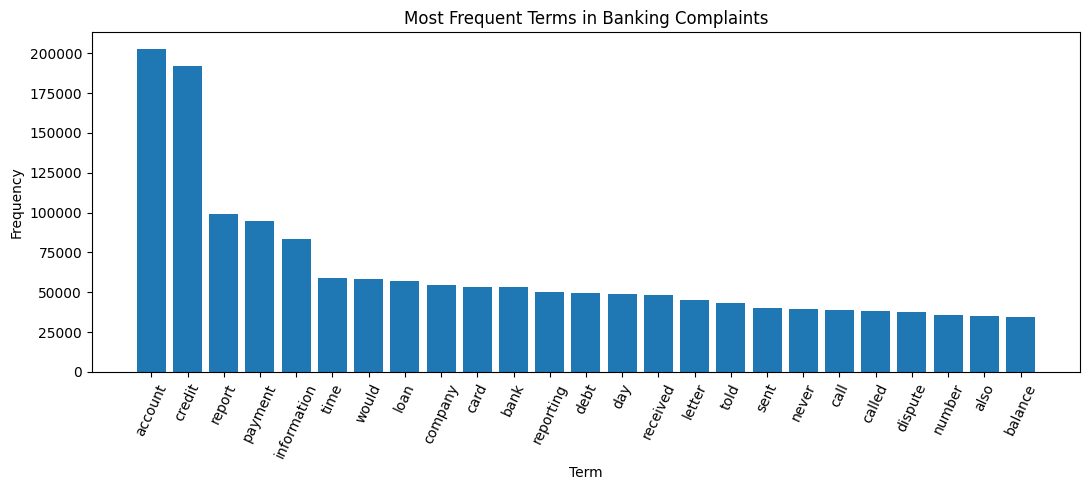

In [10]:
all_words = " ".join(df["clean_complaint"]).split()
word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(25),
    columns=["Term", "Frequency"]
)
display(top_words)

plt.figure(figsize=(11, 5))
plt.bar(top_words["Term"], top_words["Frequency"])
plt.title("Most Frequent Terms in Banking Complaints")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

## 8. Category-Specific Frequent Terms

In [11]:
for category in df[target_col].value_counts().head(5).index:
    text = " ".join(
        df.loc[df[target_col] == category, "clean_complaint"]
    ).split()
    counts = Counter(text)
    print(f"\nTop terms for: {category}")
    print([word for word, count in counts.most_common(10)])


Top terms for: credit_reporting
['credit', 'account', 'report', 'information', 'reporting', 'payment', 'dispute', 'inquiry', 'consumer', 'letter']

Top terms for: debt_collection
['debt', 'credit', 'account', 'collection', 'report', 'company', 'information', 'letter', 'received', 'payment']

Top terms for: mortgages_and_loans
['payment', 'loan', 'mortgage', 'would', 'account', 'time', 'told', 'credit', 'received', 'company']

Top terms for: credit_card
['card', 'credit', 'account', 'payment', 'bank', 'charge', 'would', 'time', 'one', 'received']

Top terms for: retail_banking
['account', 'bank', 'money', 'would', 'day', 'told', 'check', 'fund', 'time', 'transaction']


## 9. TF-IDF Feature Extraction

In [12]:
X_text = df["clean_complaint"]
y = df[target_col].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)

Training matrix: (80000, 15000)
Testing matrix: (20000, 15000)


## 10. Multinomial Naive Bayes

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred, nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_model(
    "Multinomial Naive Bayes", nb_model, X_test, y_test
)

Multinomial Naive Bayes Accuracy: 82.47%
Weighted Precision: 82.72%
Weighted Recall: 82.47%
Weighted F1-score: 82.42%

Classification Report:
                     precision    recall  f1-score   support

        credit_card       0.74      0.79      0.77      2410
   credit_reporting       0.88      0.85      0.86      9032
    debt_collection       0.81      0.70      0.75      3388
mortgages_and_loans       0.76      0.89      0.82      3009
     retail_banking       0.84      0.88      0.86      2161

           accuracy                           0.82     20000
          macro avg       0.81      0.82      0.81     20000
       weighted avg       0.83      0.82      0.82     20000



## 11. Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model(
    "Logistic Regression", lr_model, X_test, y_test
)

Logistic Regression Accuracy: 85.33%
Weighted Precision: 85.25%
Weighted Recall: 85.33%
Weighted F1-score: 85.26%

Classification Report:
                     precision    recall  f1-score   support

        credit_card       0.80      0.80      0.80      2410
   credit_reporting       0.88      0.90      0.89      9032
    debt_collection       0.82      0.75      0.78      3388
mortgages_and_loans       0.86      0.85      0.85      3009
     retail_banking       0.87      0.88      0.87      2161

           accuracy                           0.85     20000
          macro avg       0.84      0.84      0.84     20000
       weighted avg       0.85      0.85      0.85     20000



## 12. GridSearchCV

In [15]:
param_grid = {"alpha": [0.1, 0.5, 1.0]}
grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV weighted F1:", round(grid.best_score_, 4))

best_nb = grid.best_estimator_
grid_pred, grid_acc, grid_prec, grid_rec, grid_f1 = evaluate_model(
    "Tuned Multinomial Naive Bayes", best_nb, X_test, y_test
)

Best parameters: {'alpha': 0.1}
Best CV weighted F1: 0.822
Tuned Multinomial Naive Bayes Accuracy: 82.55%
Weighted Precision: 82.87%
Weighted Recall: 82.55%
Weighted F1-score: 82.55%

Classification Report:
                     precision    recall  f1-score   support

        credit_card       0.73      0.80      0.76      2410
   credit_reporting       0.88      0.84      0.86      9032
    debt_collection       0.80      0.71      0.75      3388
mortgages_and_loans       0.77      0.89      0.82      3009
     retail_banking       0.83      0.89      0.86      2161

           accuracy                           0.83     20000
          macro avg       0.80      0.82      0.81     20000
       weighted avg       0.83      0.83      0.83     20000



## 13. Model Comparison

,Model,Accuracy (%),Weighted F1 (%)
0,Multinomial NB,82.46,82.42
1,Logistic Regression,85.33,85.26
2,Tuned Multinomial NB,82.54,82.55


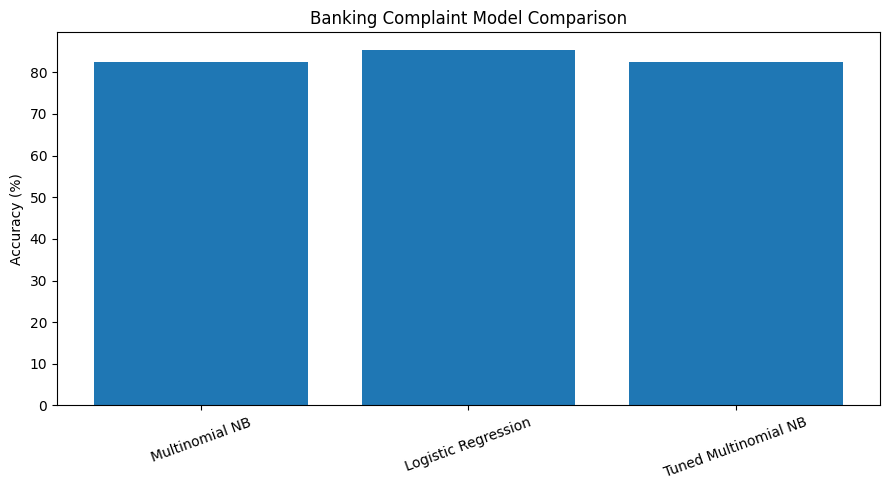

In [16]:
comparison = pd.DataFrame({
    "Model": ["Multinomial NB", "Logistic Regression", "Tuned Multinomial NB"],
    "Accuracy (%)": [nb_acc*100, lr_acc*100, grid_acc*100],
    "Weighted F1 (%)": [nb_f1*100, lr_f1*100, grid_f1*100]
})

display(comparison.round(2))

plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("Banking Complaint Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 14. Confusion Matrix

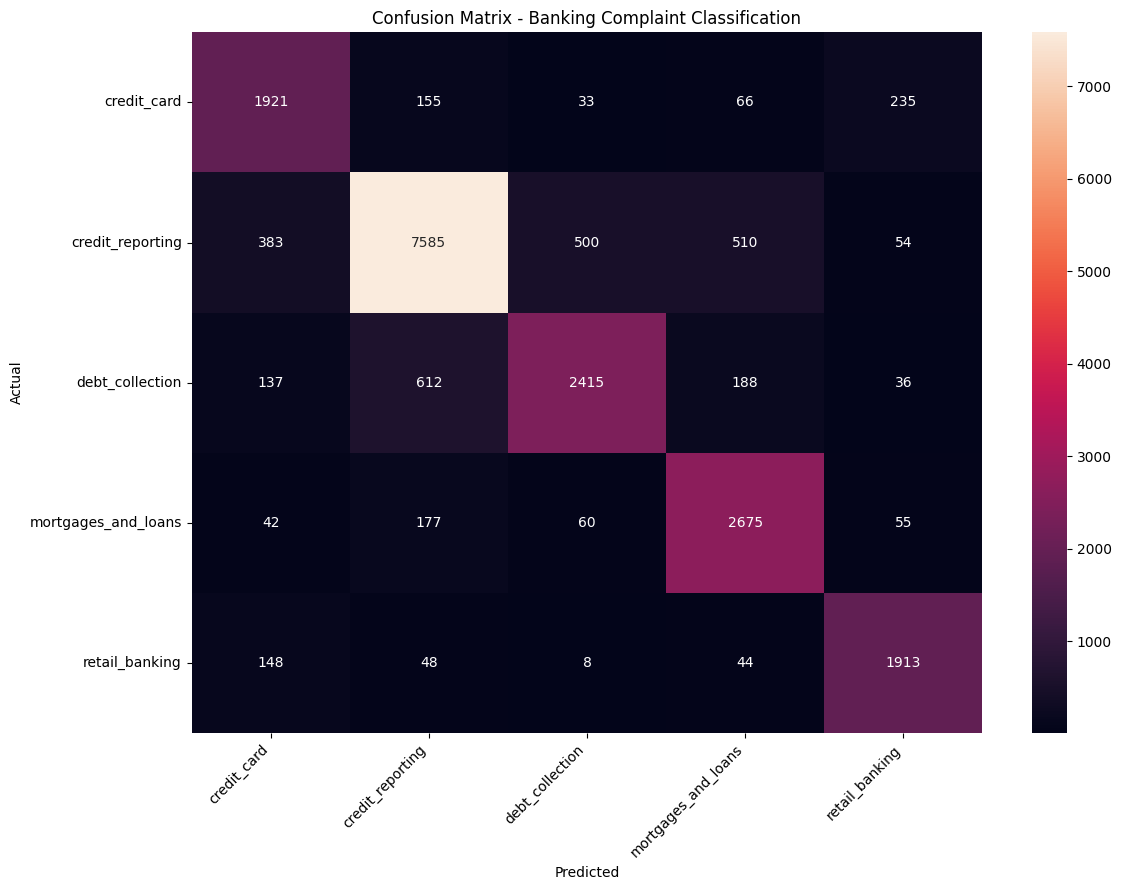

In [17]:
cm = confusion_matrix(y_test, grid_pred, labels=best_nb.classes_)
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=best_nb.classes_,
    yticklabels=best_nb.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Banking Complaint Classification")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Custom Complaint Classification

In [18]:
def predict_complaint(text):
    cleaned = preprocess_text(text)
    vector = vectorizer.transform([cleaned])
    return best_nb.predict(vector)[0]

print(predict_complaint("I was charged twice for the same credit card transaction."))
print(predict_complaint("My bank account balance has not been updated after my transfer."))

credit_card
credit_reporting


## 16. Analytical Report

In [19]:
print("BANKING COMPLAINT ANALYTICAL REPORT")
print("----------------------------------")
print("Total complaints analyzed:", len(df))
print("Number of complaint categories:", df[target_col].nunique())
print("Most frequent category:", df[target_col].value_counts().idxmax())
print("Most frequent terms:", ", ".join(top_words.head(10)["Term"]))
print("Best model by weighted F1:")

best_model_name = comparison.loc[
    comparison["Weighted F1 (%)"].idxmax(), "Model"
]
print(best_model_name)

BANKING COMPLAINT ANALYTICAL REPORT
----------------------------------
Total complaints analyzed: 100000
Number of complaint categories: 5
Most frequent category: credit_reporting
Most frequent terms: account, credit, report, payment, information, time, would, loan, company, card
Best model by weighted F1:
Logistic Regression


## 17. Conclusion

The project uses NLP techniques to preprocess financial complaint narratives and classify them into complaint/product categories. TF-IDF converts the complaint text into numerical features, while machine-learning models perform classification. Frequent terms and category distributions provide additional information about recurring financial issues.

**Important:** Accuracy, precision, recall and F1 values are generated from the actual notebook execution and are not manually fabricated.